In [1]:
# Imports #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Concatenate
from tensorflow.keras.models import Model

2026-04-05 19:33:04.559860: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/mnt/Research/Rheed-FOLO/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Constants #

IMAGE_X = 256
IMAGE_Y = 256

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

SCALE_FACTOR = 8

LABEL_X = IMAGE_X // SCALE_FACTOR
LABEL_Y = IMAGE_Y // SCALE_FACTOR

MIN_NUM_GAUSSIANS = 2
MAX_NUM_GAUSSIANS = 4

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

THRESHOLD = 0.5

# TF

In [3]:
# Tensorflow Functions #

def loss_p(y_true, y_pred):
    loss = tf.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_sum(loss)


In [5]:
# Load Model #
MODEL_NAME = '[FOLO]_[Generated]_[256].keras'


baby_yolo_tf = tf.keras.models.load_model(
    f'/mnt/Research/Rheed-FOLO/Models/{MODEL_NAME}',
    custom_objects={"loss_p": loss_p}
)


baby_yolo_tf.summary()

I0000 00:00:1775442878.410090  104675 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4681 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "baby_yolo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ x_prob (Conv2D)                 │ (None, 32, 32, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,132 (31.77 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 5,379 (21.02 KB)

# HLS4ML

In [6]:
# HLS4ML Config #
 
import hls4ml
from hls4ml.utils import config_from_keras_model

config = config_from_keras_model(baby_yolo_tf, granularity='name', backend='Vitis')
config['Model']['Strategy'] = 'Latency'
config['Model']['ReuseFactor'] = 1
hls_model = hls4ml.converters.convert_from_keras_model(
    baby_yolo_tf,
    hls_config=config,
    output_dir='../folo_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    default_precision='fixed<32,16>',
    part='xcku035-fbva676-2-e',
    project_name='folo'
)

v2 handler used for layer batch_normalization_1
v2 handler used for layer batch_normalization_2
v2 handler used for layer batch_normalization_1
v2 handler used for layer batch_normalization_2


In [7]:
# Compile Model #

hls_model.compile()

# Model Comparison

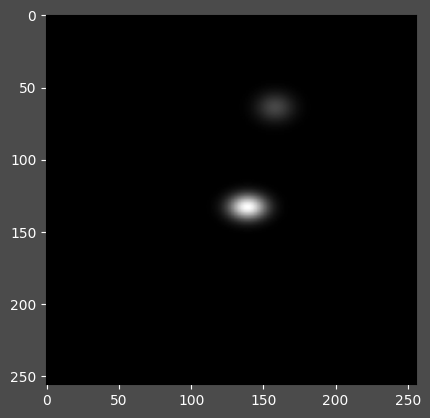

In [13]:
# Read from Stim file #

with open('/mnt/Research/RHEED/04_ref_design/sim/PP_data_folo.dat', 'r') as f:
    data = f.read()

hex_values = data.split()

int_values = [int(x, 16) for x in hex_values]

SIM_DATA = np.array(int_values).reshape(IMAGE_X, IMAGE_Y).astype(np.float32) / 255

plt.imshow(SIM_DATA, cmap='gray')

In [10]:
# Predict & Compare #

tf_pred = baby_yolo_tf.predict(np.expand_dims(SIM_DATA, 0))
hls_pred = hls_model.predict(SIM_DATA).reshape(1, LABEL_Y, LABEL_X)

2026-04-05 19:37:07.618926: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step


(7, 18) -> 0.0068084015510976315
(7, 19) -> 0.2269010990858078
(7, 20) -> 0.01868424564599991
(8, 18) -> 0.005767399910837412
(8, 19) -> 0.2723337411880493
(8, 20) -> 0.06381890922784805
(16, 16) -> 0.06439259648323059
(16, 17) -> 0.9967855215072632
(16, 18) -> 0.004240098875015974


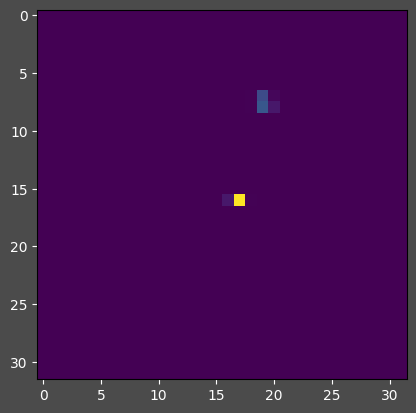

In [11]:
plt.imshow(tf_pred[0, :, :, 0])
coords = np.argwhere(tf_pred[0, :, :, 0] >= 1e-3)

for (i, j) in coords:
    print(f"({i}, {j}) -> {tf_pred[0, :, :, 0][i, j]}")

(7, 18) -> 0.005859375
(7, 19) -> 0.22265625
(7, 20) -> 0.0185546875
(8, 18) -> 0.0048828125
(8, 19) -> 0.2685546875
(8, 20) -> 0.0634765625
(16, 16) -> 0.05859375
(16, 17) -> 0.99609375
(16, 18) -> 0.00390625


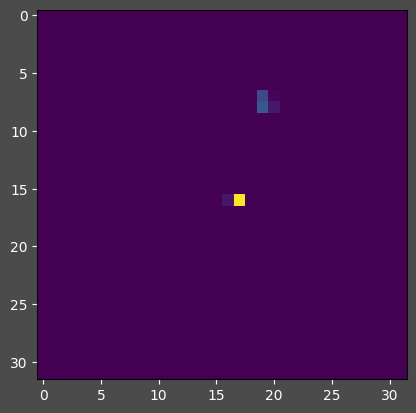

In [12]:
plt.imshow(hls_pred[0])
coords = np.argwhere(hls_pred[0] >= 1e-3)

for (i, j) in coords:
    print(f"({i}, {j}) -> {hls_pred[0][i, j]}")

(7, 19) -> 2.0
(7, 20) -> 182.0
(7, 21) -> 45.0
(8, 19) -> 2.0
(8, 20) -> 217.0
(8, 21) -> 143.0
(16, 17) -> 33.0
(16, 18) -> 1020.0
(16, 19) -> 10.0


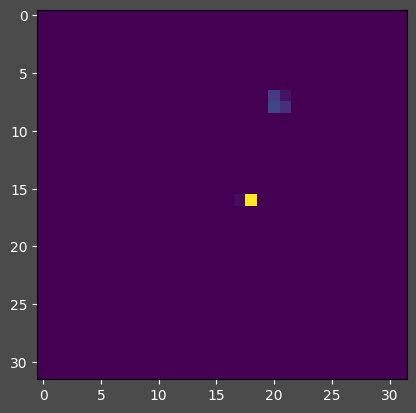

In [14]:
# Read from Res file #

data = np.loadtxt("/mnt/Research/RHEED/04_ref_design/sim/PP_FOLO_RES", dtype=float)

image = data.reshape((32, 32))

plt.imshow(image)

coords = np.argwhere(image >= 1e-3)

for (i, j) in coords:
    print(f"({i}, {j}) -> {image[i, j]}")
